In [ ]:
!pip install pandas numpy matplotlib seaborn

# **Import các thư viện cần thiết**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler

# **Đọc file**

In [ ]:

file_path = '/content/drive/MyDrive/DataScienceGroup/bank-full.csv'
df = pd.read_csv(file_path, sep=';')

display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Kiểm tra các kiểu dữ liệu và giá trị còn thiếu

###Nhiệm vụ phụ:
Kiểm tra dữ liệu kiểu của từng cột và xác định thiếu giá trị số lượng (nếu có) để hiểu rõ hơn về dữ liệu trạng thái.

**Thực Hiện**:
Trước tiên, sẽ hiển thị các kiểu dữ liệu của từng cột trong DataFrame bằng cách sử dụng `df.info()` để nhận bản tóm tắt về DataFrame bao gồm các kiểu dữ liệu, giá trị không rỗng và mức sử dụng bộ nhớ. Sau đó, tôi sẽ tính số giá trị còn thiếu cho mỗi cột bằng cách sử dụng `df.isnull().sum()`.

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None
age          0
job          0
marital      0
education    0
default      0
balance      0
hous

## Xử lý các giá trị bị thiếu

###Nhiệm vụ phụ:
Xử lý việc thiếu giá trị trong DataFrame, có thể bằng cách điền giá trị thích hợp (ví dụ: trung bình, trung vị, chế độ) hoặc loại bỏ các hàng/cột có quá nhiều giá trị bị thiếu.

Trong bước trước đó, đã sử dụng `df.info()` và `df.isnull().sum()` đã xác nhận rằng không có giá trị nào bị thiếu trong DataFrame `df` trên tất cả các cột. Do đó, không cần thực hiện thêm hành động nào để xử lý các giá trị bị thiếu ở giai đoạn này.

## Mã hóa các biến phân loại

###Nhiệm vụ phụ:
Chuyển đổi loại phân loại biến (chữ chữ) thành định dạng để máy học mô hình có thể xử lý được.

**Thực hiện**:
Đầu tiên, in các giá trị duy nhất và số lượng của chúng cho cột 'y' để hiểu sự phân bố của nó và xác nhận tính chất phân loại của nó. Sau đó, tôi sẽ xác định tất cả các cột phân loại (dtype đối tượng) trong DataFrame, ngoại trừ biến mục tiêu 'y'.

In [ ]:
print(df['y'].value_counts())
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('y')
print("Các cột phân loại cần mã hóa (trừ 'y'):", categorical_cols)

y
no     39922
yes     5289
Name: count, dtype: int64
Các cột phân loại cần mã hóa (trừ 'y'): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


chuyển đổi cột 'y' thành các giá trị số (1 cho 'có', 0 cho 'không') rồi áp dụng mã hóa một lần cho các cột phân loại đã xác định bằng cách sử dụng `pd.get_dummies()` để chuyển đổi chúng thành định dạng số phù hợp cho các mô hình học máy, cập nhật DataFrame tại chỗ.

In [ ]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.head())
print(df.shape)

   age  balance  day  duration  campaign  pdays  previous  y  job_blue-collar  \
0   58     2143    5       261         1     -1         0  0            False   
1   44       29    5       151         1     -1         0  0            False   
2   33        2    5        76         1     -1         0  0            False   
3   47     1506    5        92         1     -1         0  0             True   
4   33        1    5       198         1     -1         0  0            False   

   job_entrepreneur  ...  month_jul  month_jun  month_mar  month_may  \
0             False  ...      False      False      False       True   
1             False  ...      False      False      False       True   
2              True  ...      False      False      False       True   
3             False  ...      False      False      False       True   
4             False  ...      False      False      False       True   

   month_nov  month_oct  month_sep  poutcome_other  poutcome_success  \
0      F

## Chia tỷ lệ tính năng

###Nhiệm vụ phụ:
Chuẩn hóa hoặc điều chỉnh tỷ lệ các biến nếu cần thiết để đảm bảo các ảnh cân bằng cụ thể bằng mô hình.

Đầu tiên, xác định tất cả các cột số trong DataFrame `df`, ngoại trừ biến mục tiêu 'y', để chuẩn bị cho việc chia tỷ lệ. Sau đó tôi sẽ hiển thị các cột được xác định này.

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'y' in numerical_cols:
    numerical_cols.remove('y')
print("Các cột số cần chia tỷ lệ:", numerical_cols)

Các cột số cần chia tỷ lệ: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


Nhập `StandardScaler`, khởi tạo nó và áp dụng nó cho các cột số đã xác định trong DataFrame để chia tỷ lệ cho chúng. Cuối cùng, hiển thị một số hàng đầu tiên của DataFrame đã sửa đổi để xác minh tỷ lệ.

In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df.head())

        age   balance       day  duration  campaign     pdays  previous  y  \
0  1.606965  0.256419 -1.298476  0.011016 -0.569351 -0.411453  -0.25194  0   
1  0.288529 -0.437895 -1.298476 -0.416127 -0.569351 -0.411453  -0.25194  0   
2 -0.747384 -0.446762 -1.298476 -0.707361 -0.569351 -0.411453  -0.25194  0   
3  0.571051  0.047205 -1.298476 -0.645231 -0.569351 -0.411453  -0.25194  0   
4 -0.747384 -0.447091 -1.298476 -0.233620 -0.569351 -0.411453  -0.25194  0   

   job_blue-collar  job_entrepreneur  ...  month_jul  month_jun  month_mar  \
0            False             False  ...      False      False      False   
1            False             False  ...      False      False      False   
2            False              True  ...      False      False      False   
3             True             False  ...      False      False      False   
4            False             False  ...      False      False      False   

   month_may  month_nov  month_oct  month_sep  poutcome_other 

## Trực quan hóa phân phối của biến 'age'

Để hiểu rõ hơn về phân phối của biến 'age', sử dụng cả biểu đồ histogram (kèm đường KDE) và biểu đồ box plot.

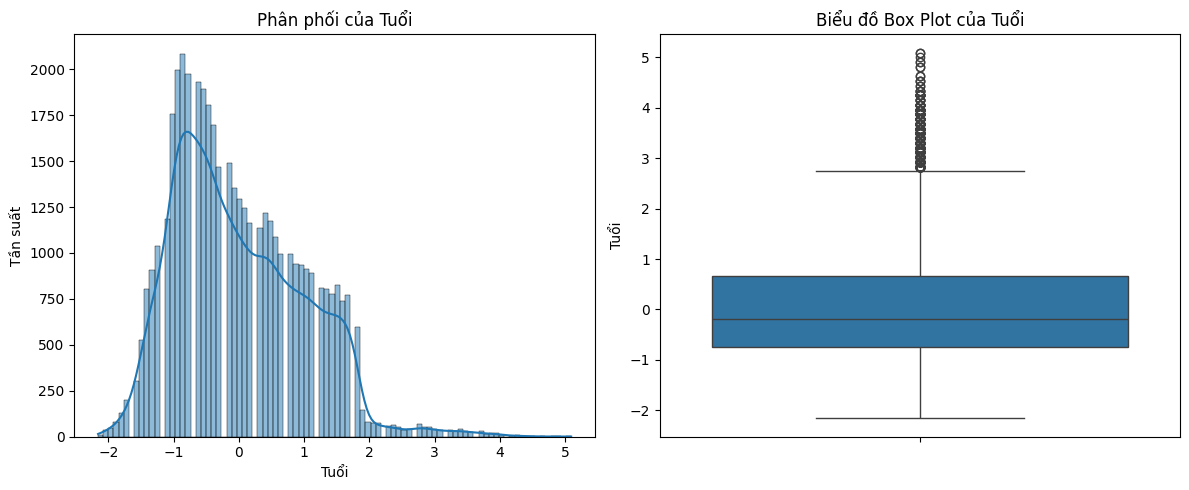

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Phân phối của Tuổi')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Biểu đồ Box Plot của Tuổi')
plt.ylabel('Tuổi')

plt.tight_layout()
plt.show()

## Trực quan hóa phân phối biến số số

### Nhiệm vụ phụ:
Hiển thị phân phối của các biến số số (ví dụ: 'age', 'balance', 'duration') bằng biểu đồ histogram hoặc box plot để kiểm tra hình dạng phân phối, các giá trị ngoại lệ và xu hướng trung tâm.


Lặp qua các cột số đã xác định, tạo biểu đồ bằng KDE và biểu đồ hộp cho mỗi cột. Điều này sẽ cung cấp thông tin chi tiết về sự phân bố, các ngoại lệ tiềm năng và xu hướng trung tâm của chúng, bằng cách sử dụng `matplotlib.pyplot` để đảm bảo mỗi cặp ô được hiển thị riêng lẻ để phân tích rõ ràng.

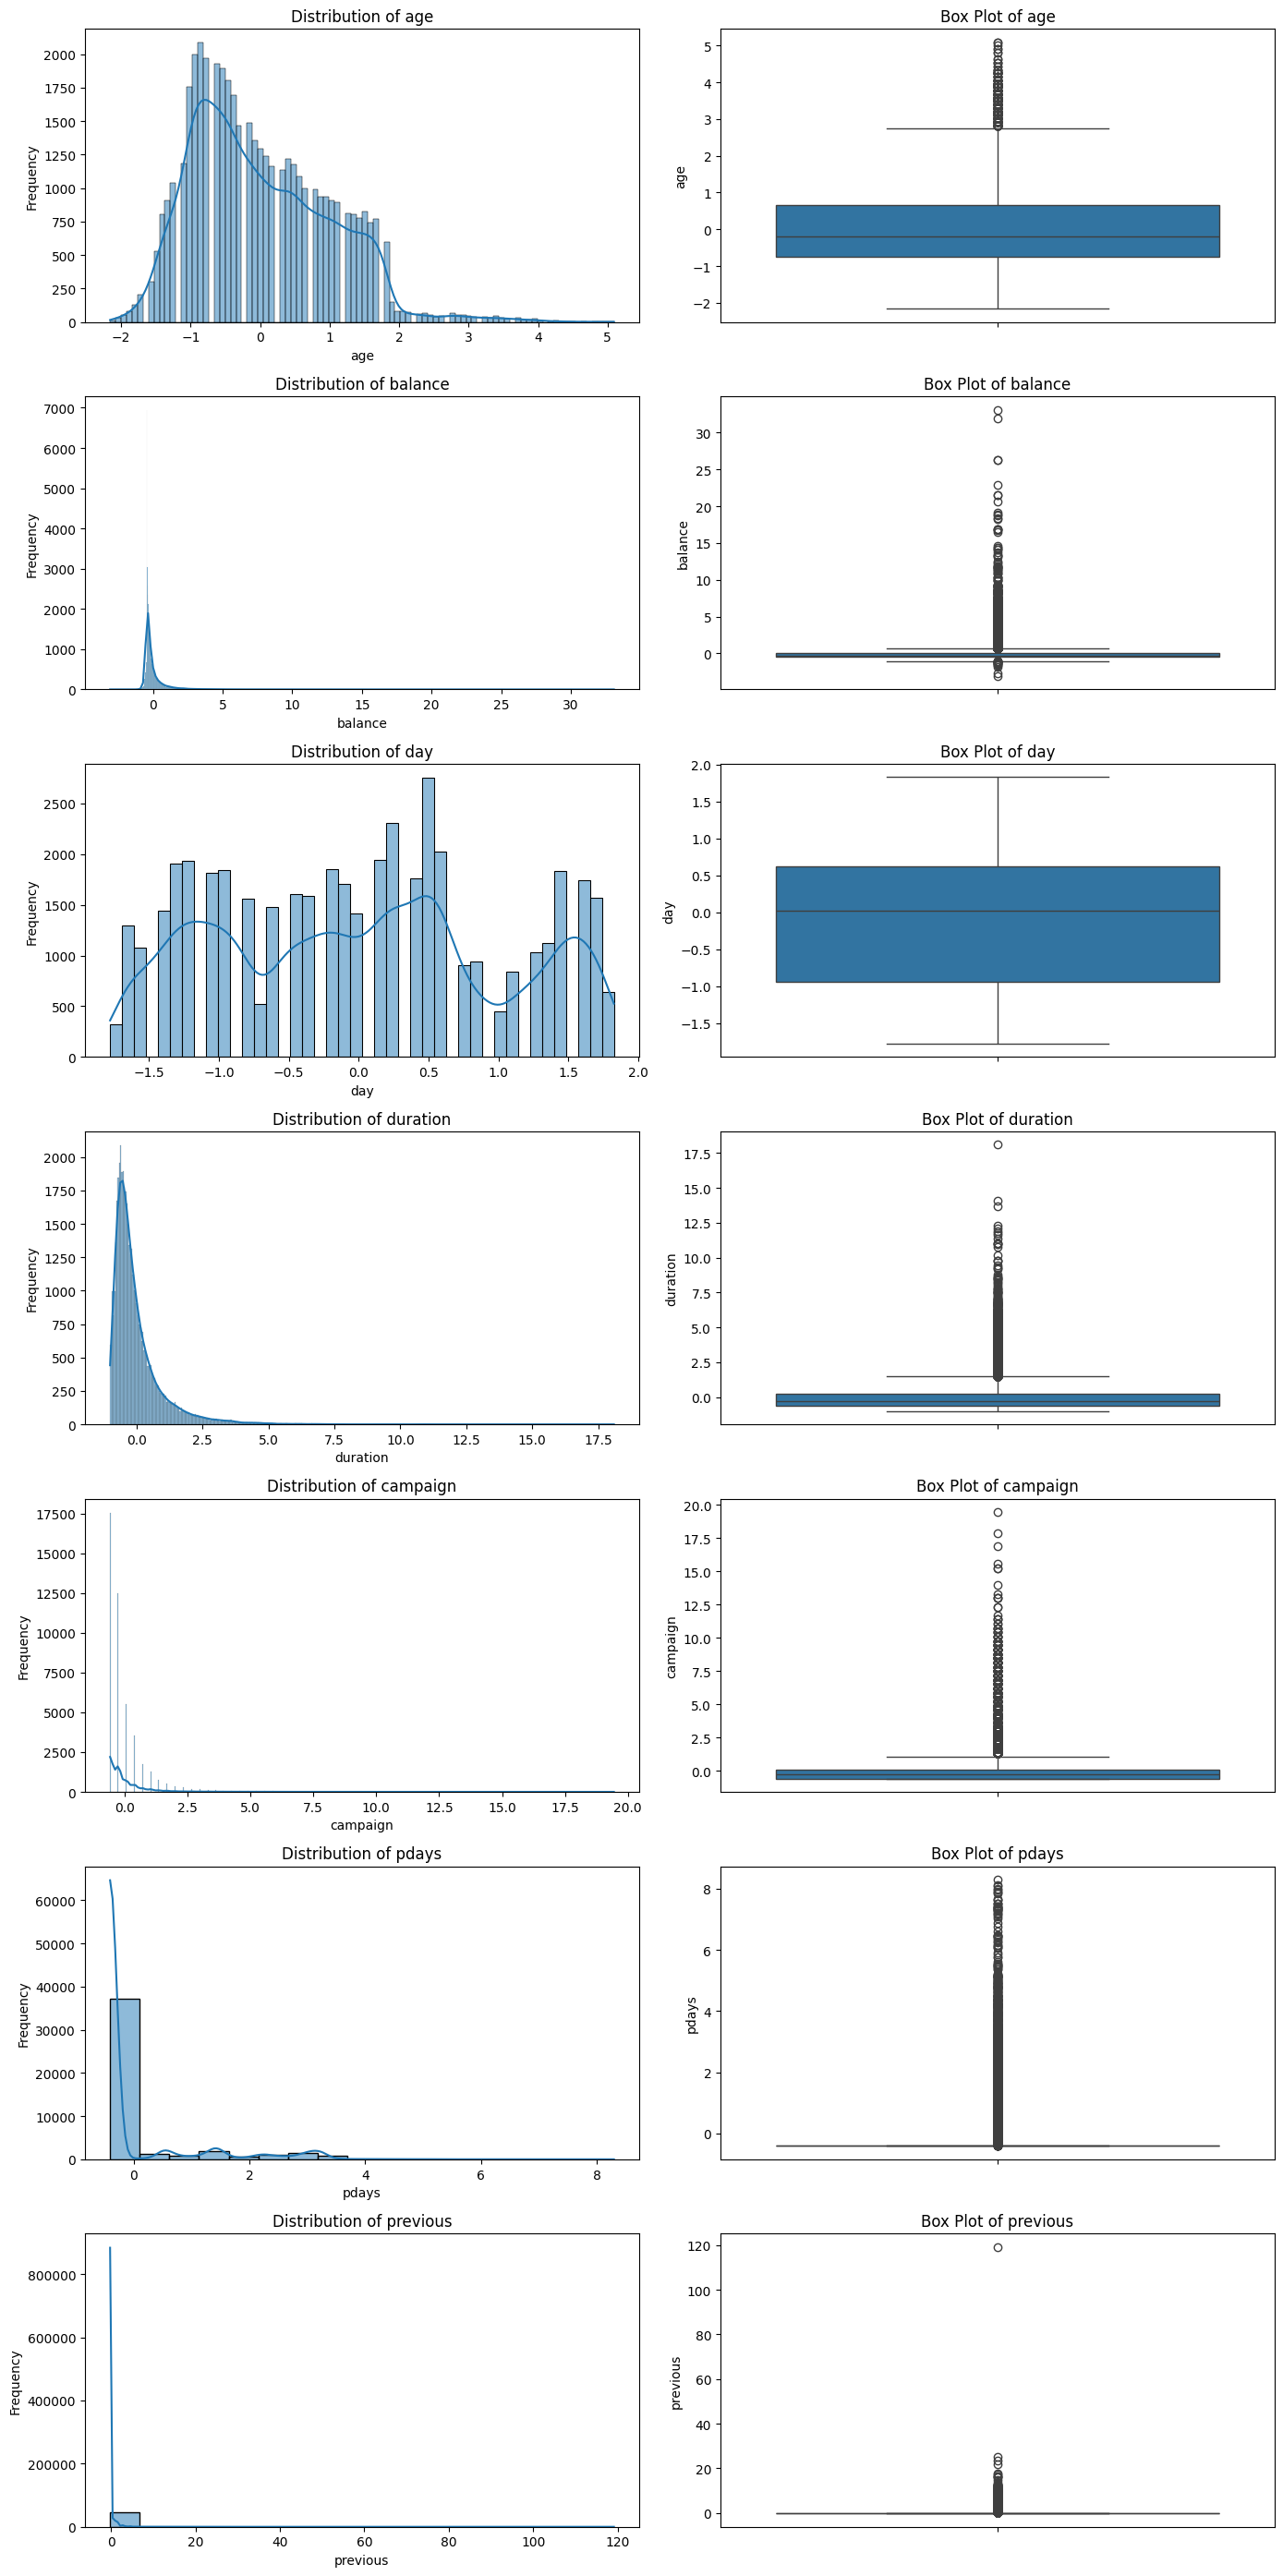

In [ ]:
import math

# Calculate the number of rows and columns for the grid
num_numerical_cols = len(numerical_cols)
rows = num_numerical_cols
cols = 2 # One column for histogram, one for box plot

plt.figure(figsize=(cols * 7, rows * 4)) # Adjust figure size dynamically for 2 plots per row

for i, col in enumerate(numerical_cols):
    # Plot Histogram
    plt.subplot(rows, cols, i * cols + 1) # Position for histogram
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Plot Box plot
    plt.subplot(rows, cols, i * cols + 2) # Position for box plot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Trực quan hóa mối quan hệ giữa biến số phân loại và biến mục tiêu

### Nhiệm vụ phụ:
Sử dụng biểu đồ thanh (bar plots) hoặc biểu đồ đếm (count plots) để khám phá mối quan hệ giữa các biến phân loại (ví dụ: 'job', 'marital', 'education') và biến mục tiêu ('y').


Lặp qua từng cột phân loại được xác định trước đó trong `categorical_cols` và tạo một biểu đồ thanh được nhóm bằng cách sử dụng `seaborn.countplot` để trực quan hóa sự phân bố của nó so với biến mục tiêu 'y'. Điều này sẽ liên quan đến việc thiết lập cột phân loại trên trục x, sử dụng `hue='y'` để phân biệt, thêm tiêu đề và nhãn thích hợp, xoay nhãn trục x nếu cần và hiển thị từng ô riêng lẻ.

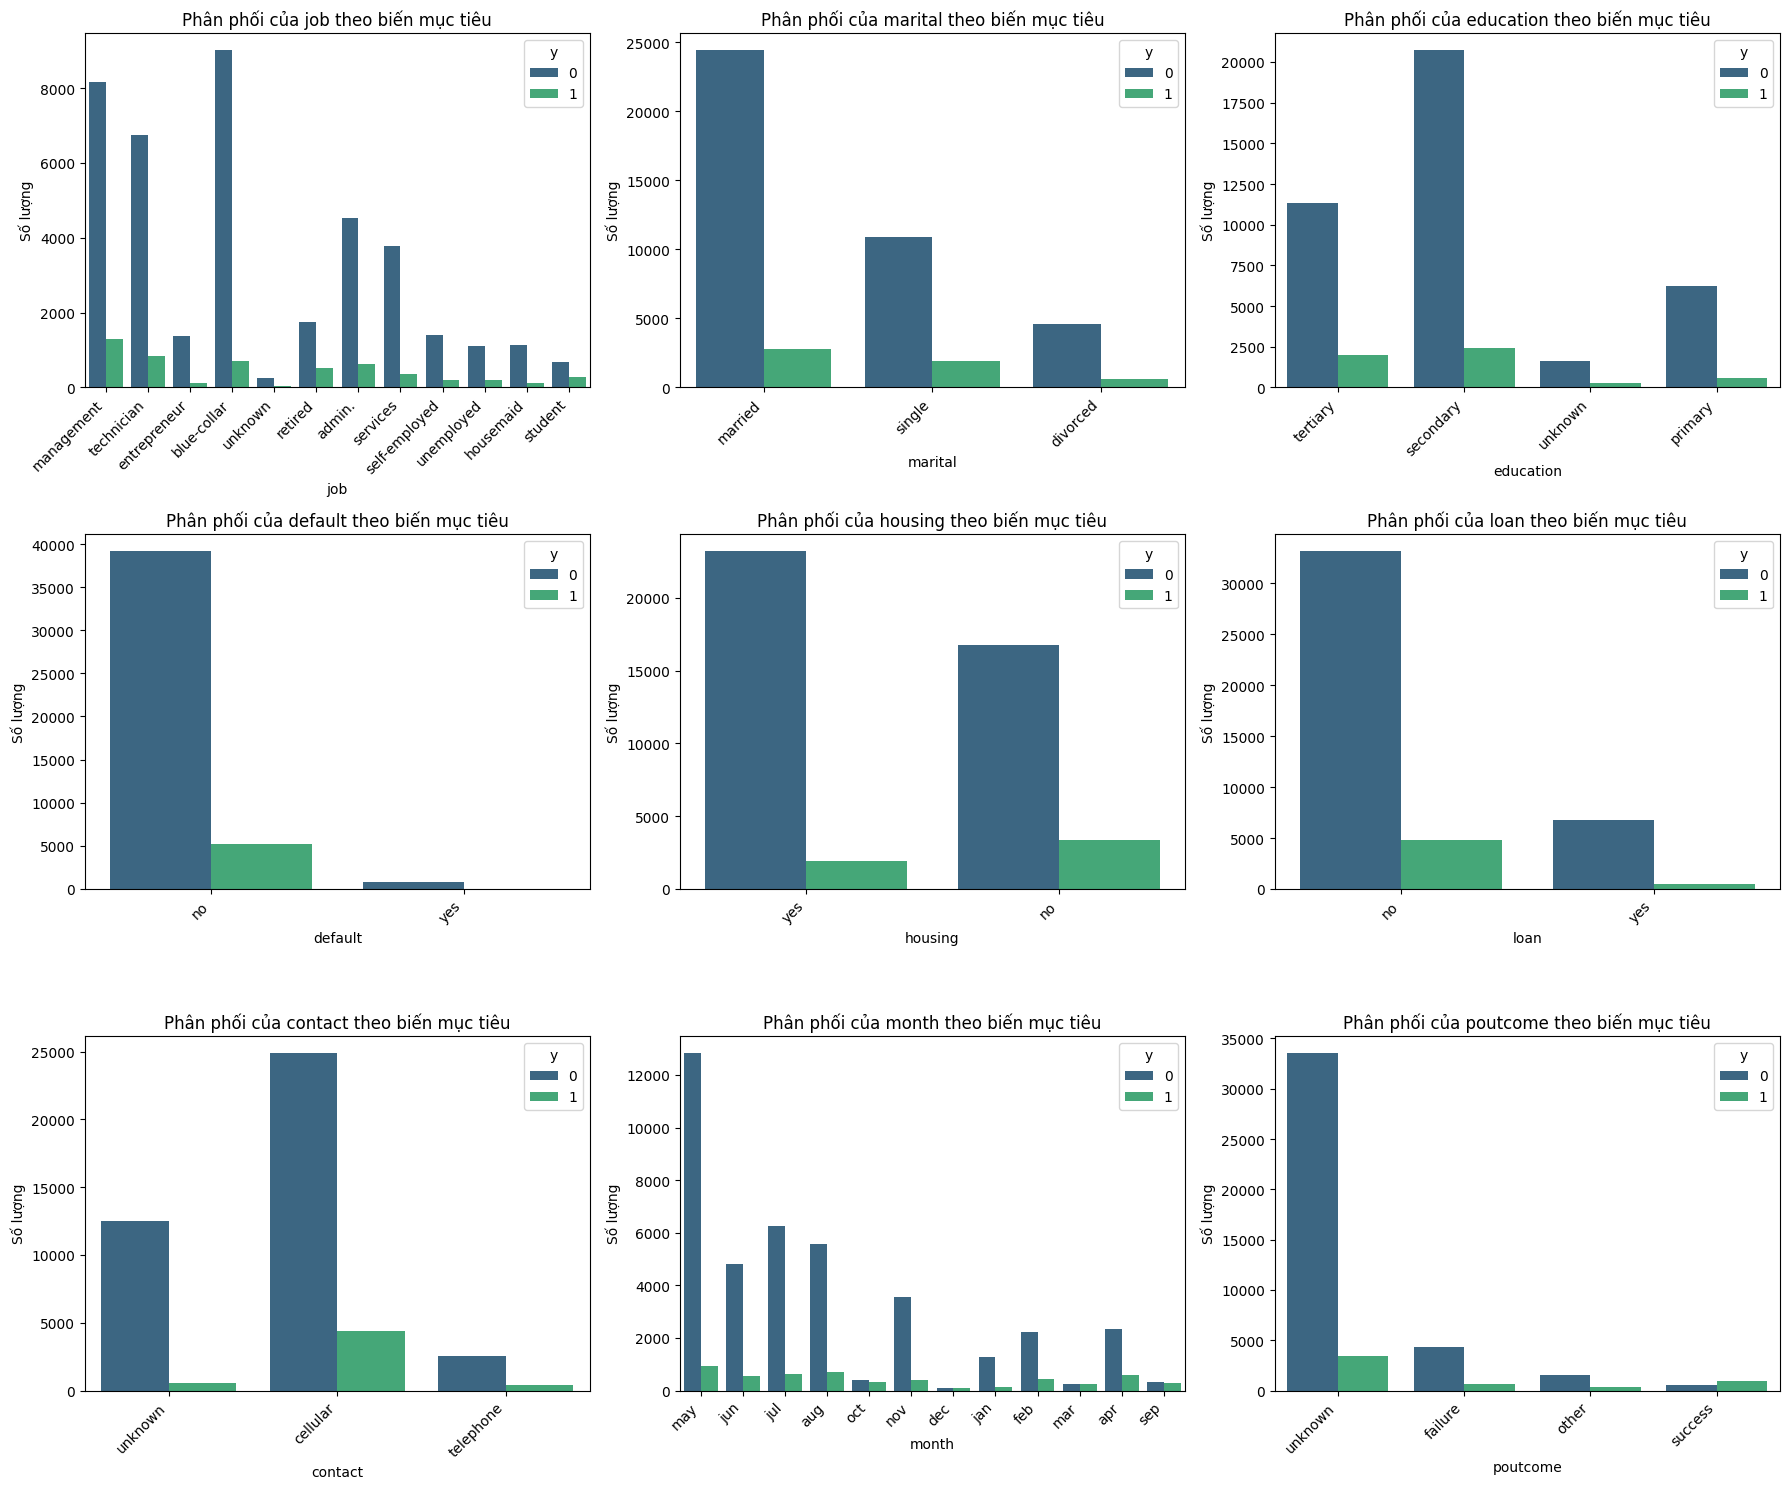

In [ ]:
import math

df_viz = pd.read_csv(file_path, sep=';')

# Convert the 'y' column to numerical values (1 for 'yes', 0 for 'no') for df_viz
df_viz['y'] = df_viz['y'].map({'yes': 1, 'no': 0})

# Calculate the number of rows and columns for the grid
num_cols_to_plot = len(categorical_cols)
cols_per_row = 3 # You can adjust this number
rows = math.ceil(num_cols_to_plot / cols_per_row)

plt.figure(figsize=(cols_per_row * 6, rows * 5)) # Adjust figure size dynamically

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, cols_per_row, i + 1)
    sns.countplot(data=df_viz, x=col, hue='y', palette='viridis')
    plt.title(f'Phân phối của {col} theo biến mục tiêu')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Trực quan hóa mối quan hệ giữa biến số số và biến mục tiêu

### Nhiệm vụ phụ:
Sử dụng biểu đồ box plot hoặc violin plot để hình dung mối quan hệ giữa các biến số số và biến mục tiêu ('y'), giúp xác định các sự khác biệt trong phân phối dựa trên kết quả mục tiêu.


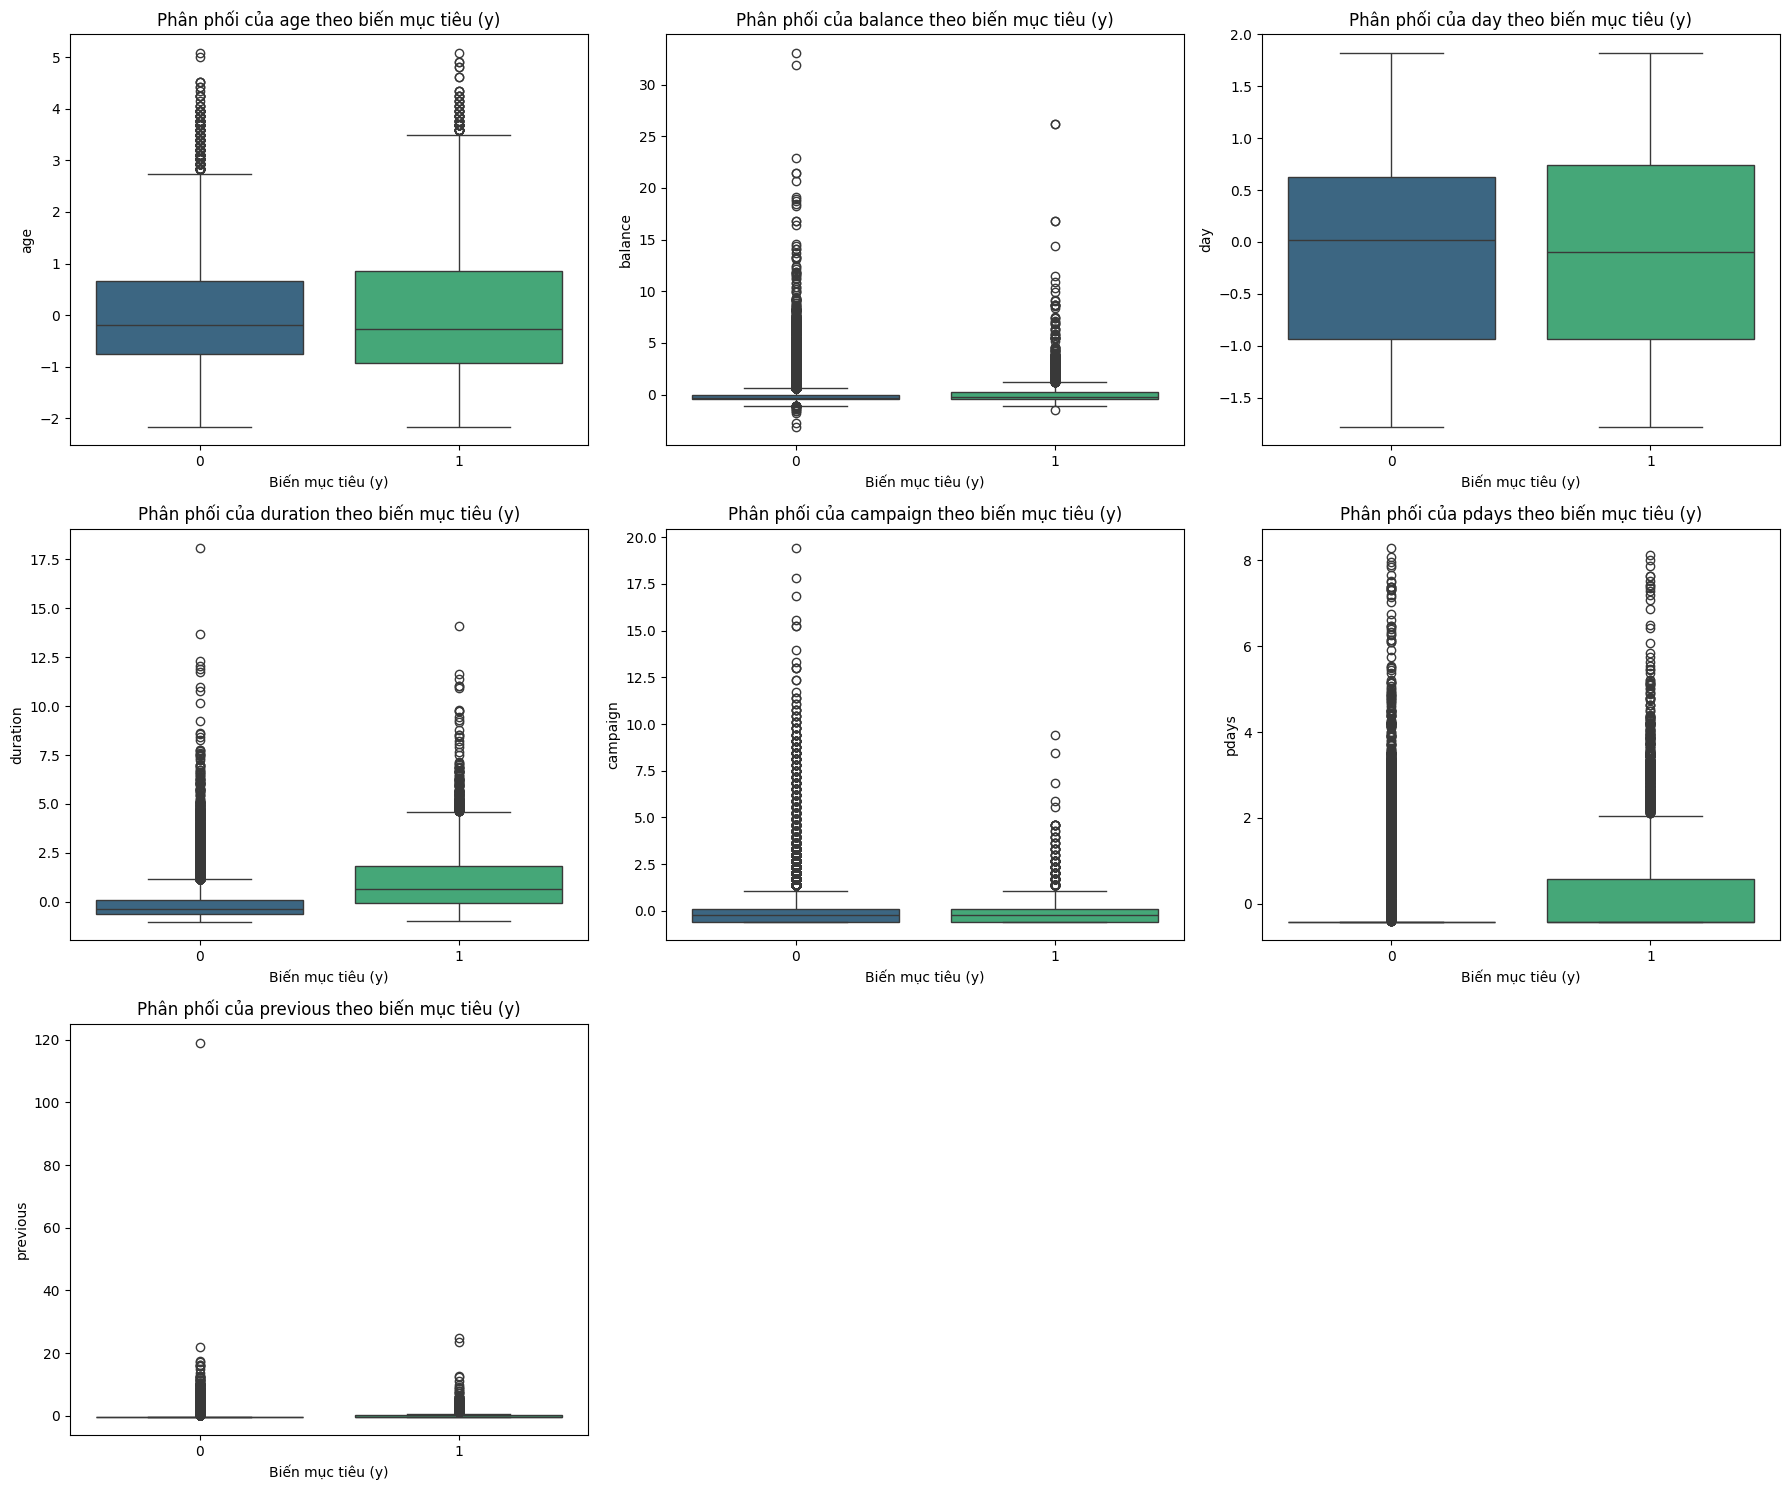

In [ ]:
import math

# Calculate the number of rows and columns for the grid
num_cols_to_plot = len(numerical_cols)
rows = math.ceil(num_cols_to_plot / 3) # Max 3 plots per row

plt.figure(figsize=(18, rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1) # Create subplot for each numerical column
    sns.boxplot(data=df, x='y', y=col, hue='y', palette='viridis', legend=False)
    plt.title(f'Phân phối của {col} theo biến mục tiêu (y)')
    plt.xlabel('Biến mục tiêu (y)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Trực quan hóa ma trận tương quan

### Subtask:
Tạo ma trận tương quan (heatmap) giữa tất cả các biến số số để hiểu rõ hơn về mối quan hệ tuyến tính giữa chúng.


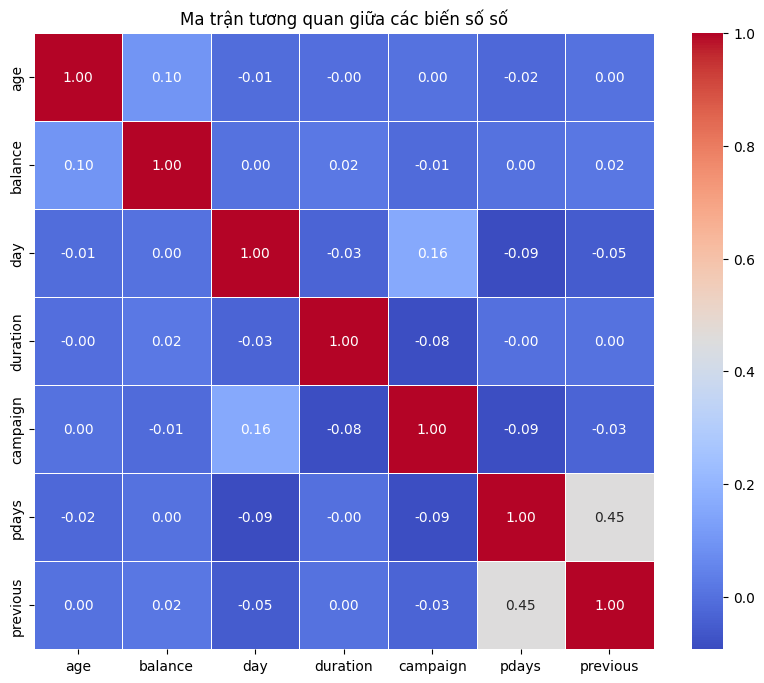

In [ ]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Ma trận tương quan giữa các biến số số')
plt.show()

## Biểu đồ phân tán giữa các biến số theo biến mục tiêu `y`

Biểu đồ dưới đây minh họa mối quan hệ giữa các biến số trong bộ dữ liệu **Bank Marketing**, đồng thời so sánh sự khác biệt giữa hai nhóm khách hàng **đăng ký** và **không đăng ký** tiền gửi có kỳ hạn thông qua biến mục tiêu `y`.

- **Biểu đồ bên trái** thể hiện mối quan hệ giữa biến **`previous`** (số lần khách hàng đã được liên hệ trong các chiến dịch trước) và **`pdays`** (số ngày kể từ lần liên hệ gần nhất).  
  Việc phân màu theo `y` giúp quan sát sự khác biệt trong lịch sử liên hệ giữa hai nhóm khách hàng.

- **Biểu đồ bên phải** mô tả mối quan hệ giữa **tuổi khách hàng (`age`)** và **số dư trung bình hàng năm (`balance`)**.  
  Biểu đồ hỗ trợ nhận diện xu hướng phân bố số dư theo độ tuổi và đánh giá ảnh hưởng của hai biến này đến khả năng đăng ký tiền gửi.

Các biểu đồ phân tán giúp cung cấp cái nhìn trực quan ban đầu về mối quan hệ giữa các biến, từ đó hỗ trợ quá trình lựa chọn và xây dựng mô hình học máy ở các bước tiếp theo.


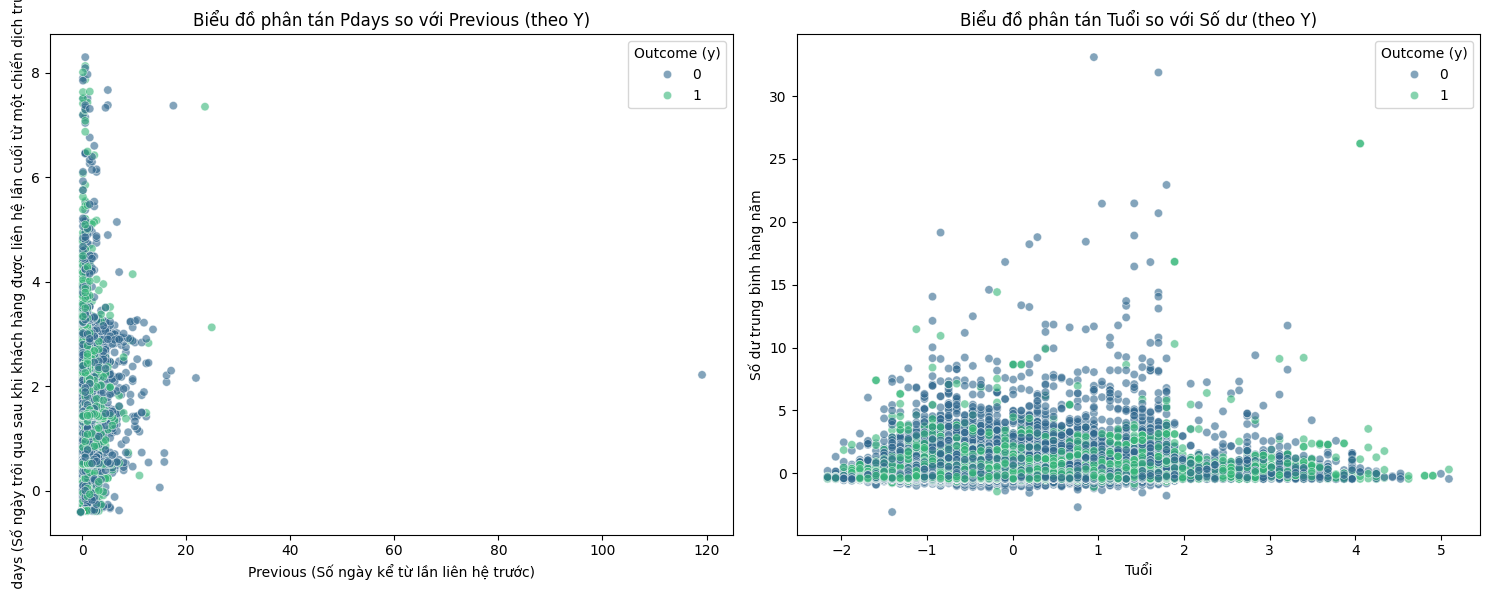

In [ ]:
plt.figure(figsize=(15, 6))

# Scatter plot for 'pdays' vs 'previous', colored by 'y'
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='previous', y='pdays', hue='y', palette='viridis', alpha=0.6)
plt.title('Biểu đồ phân tán Pdays so với Previous (theo Y)')
plt.xlabel('Previous (Số ngày kể từ lần liên hệ trước)')
plt.ylabel('Pdays (Số ngày trôi qua sau khi khách hàng được liên hệ lần cuối từ một chiến dịch trước)')
plt.legend(title='Outcome (y)')

# Scatter plot for 'age' vs 'balance', colored by 'y'
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='balance', hue='y', palette='viridis', alpha=0.6)
plt.title('Biểu đồ phân tán Tuổi so với Số dư (theo Y)')
plt.xlabel('Tuổi')
plt.ylabel('Số dư trung bình hàng năm')
plt.legend(title='Outcome (y)')

plt.tight_layout()
plt.show()

# **ML**

## Huấn luyện và Đánh giá Mô hình Hồi quy Tuyến tính

Tôi sẽ thực hiện các bước sau:

1.  **Chuẩn bị dữ liệu**: Xác định các biến độc lập (predictors) là các cột số (`numerical_cols`) và biến phụ thuộc (outcome) là cột 'y'.
2.  **Chia dữ liệu**: Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra.
3.  **Khởi tạo mô hình**: Khởi tạo mô hình `LinearRegression`.
4.  **Huấn luyện mô hình**: Huấn luyện mô hình trên tập huấn luyện.
5.  **Dự đoán**: Thực hiện dự đoán trên tập kiểm tra.
6.  **Đánh giá mô hình**: Tính toán hệ số xác định R-squared (R²) và sai số trung bình bình phương gốc (RMSE) để đánh giá hiệu suất của mô hình.

In [ ]:
from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split

# Xác định biến độc lập (X) và biến phụ thuộc (y)
# Chúng ta sẽ sử dụng chỉ một cột số làm biến độc lập
X = df[['age']]
y = df['y']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
# Sử dụng train_size=0.7 để có đủ dữ liệu cho huấn luyện, và shuffle=True để đảm bảo tính ngẫu nhiên
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, train_size=0.7, random_state=42)

# Khởi tạo mô hình hồi quy tuyến tính
model = linear_model.LinearRegression()

# Huấn luyện mô hình trên tập huấn luyện
model.fit(X_train, y_train)

# Thực hiện dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá hiệu suất của mô hình
r2 = metrics.r2_score(y_test, y_pred)
rmse = (metrics.mean_squared_error(y_test, y_pred))**0.5 # Lấy căn bậc hai để có RMSE

print(f"Hệ số xác định R^2 = {r2:.4f}")
print(f"Sai số trung bình bình phương gốc (RMSE) = {rmse:.6f}")

Hệ số xác định R^2 = 0.0004
Sai số trung bình bình phương gốc (RMSE) = 0.322327


In [ ]:
from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split

# Xác định biến độc lập (X) và biến phụ thuộc (y)
# Chúng ta sẽ sử dụng hai cột số làm biến độc lập
X = df[['age', 'balance']]
y = df['y']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
# Sử dụng train_size=0.7 để có đủ dữ liệu cho huấn luyện, và shuffle=True để đảm bảo tính ngẫu nhiên
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, train_size=0.7, random_state=42)

# Khởi tạo mô hình hồi quy tuyến tính
model = linear_model.LinearRegression()

# Huấn luyện mô hình trên tập huấn luyện
model.fit(X_train, y_train)

# Thực hiện dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá hiệu suất của mô hình
r2 = metrics.r2_score(y_test, y_pred)
rmse = (metrics.mean_squared_error(y_test, y_pred))**0.5 # Lấy căn bậc hai để có RMSE

print(f"Hệ số xác định R^2 = {r2:.4f}")
print(f"Sai số trung bình bình phương gốc (RMSE) = {rmse:.6f}")

Hệ số xác định R^2 = 0.0030
Sai số trung bình bình phương gốc (RMSE) = 0.321909


In [ ]:
from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split

# Xác định các biến dự đoán (predictors) và biến mục tiêu (outcome)
# Sử dụng các cột số đã được chuẩn hóa và một cột phân loại đã mã hóa
predictors = ['age', 'balance', 'housing_yes']
outcome = 'y'

X = df[predictors]
y = df[outcome]

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
# Sử dụng train_size=0.7 để có đủ dữ liệu cho huấn luyện, và shuffle=True để đảm bảo tính ngẫu nhiên
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, train_size=0.7, random_state=42)

# Khởi tạo mô hình hồi quy tuyến tính
model = linear_model.LinearRegression()

# Huấn luyện mô hình trên tập huấn luyện
model.fit(X_train, y_train)

# Thực hiện dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá hiệu suất của mô hình
r2 = metrics.r2_score(y_test, y_pred)
rmse = (metrics.mean_squared_error(y_test, y_pred))**0.5 # Lấy căn bậc hai để có RMSE

print(f"Hệ số xác định R^2 = {r2:.4f}")
print(f"Sai số trung bình bình phương gốc (RMSE) = {rmse:.6f}")

Hệ số xác định R^2 = 0.0217
Sai số trung bình bình phương gốc (RMSE) = 0.318864


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Xác định các biến dự đoán (predictors) và biến mục tiêu (outcome)
predictors = ['age','balance','housing_yes']
outcome = 'y'

X = df[predictors]
y = df[outcome]

# Chuyển đổi cột 'housing_yes' từ boolean sang số nguyên (0 hoặc 1)
X['housing_yes'] = X['housing_yes'].astype(int)

# Thêm hằng số vào các biến độc lập
X = sm.add_constant(X)

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, train_size=0.7, random_state=42)

# Huấn luyện mô hình OLS
model = sm.OLS(y_train, X_train)
res = model.fit()

# In tóm tắt kết quả
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     226.9
Date:                Tue, 13 Jan 2026   Prob (F-statistic):          1.14e-145
Time:                        17:21:13   Log-Likelihood:                -8605.4
No. Observations:               31647   AIC:                         1.722e+04
Df Residuals:                   31643   BIC:                         1.725e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1655      0.003     61.094      

/tmp/ipython-input-11205322.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['housing_yes'] = X['housing_yes'].astype(int)


# Nhiệm vụ
Chuẩn bị dữ liệu cho Machine Learning bằng cách xác định các tính năng (X) là tất cả các cột trong `df` ngoại trừ 'y' và mục tiêu (y) là cột 'y'. Chia dữ liệu thành các tập huấn luyện và tập kiểm tra bằng cách sử dụng `train_test_split` với kích thước kiểm tra là 30% và `random_state=42`. Sau đó, huấn luyện mô hình hồi quy logistic trên dữ liệu huấn luyện và đánh giá hiệu suất của nó trên tập kiểm tra bằng cách sử dụng điểm chính xác, ma trận nhầm lẫn và báo cáo phân loại.

## Chuẩn bị dữ liệu cho ML

###Nhiệm vụ phụ:
Xác định các biến độc lập (tính năng) X và mục tiêu (đích) y từ DataFrame đã được xử lý (df). Sau đó, chia dữ liệu thành huấn luyện viên (bộ huấn luyện) và kiểm tra (bộ kiểm tra) bằng cách sử dụng `train_test_split` từ scikit-learn.

In [ ]:
from sklearn.model_selection import train_test_split

# Define feature matrix X and target variable y
X = df.drop('y', axis=1)
y = df['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước y_test: {y_test.shape}")

Kích thước X_train: (31647, 42)
Kích thước X_test: (13564, 42)
Kích thước y_train: (31647,)
Kích thước y_test: (13564,)


## **Huấn luyện mô hình hồi quy logistic**

###Nhiệm vụ phụ:
Khởi tạo và huấn luyện mô hình Hồi quy Logistic (LogisticRegression) trên huấn luyện viên tài liệu đã chia. Mô hình này phù hợp cho phân loại nhị phân phân loại toán học.

**Lý do**:
Để khởi tạo và huấn luyện mô hình Hồi quy logistic, cần import `LogisticRegression` từ `sklearn.linear_model`, tạo một phiên bản của mô hình rồi khớp nó với dữ liệu huấn luyện `X_train` và `y_train`.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Khởi tạo mô hình hồi quy logistic
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for small datasets or L1/L2 regularization

# Huấn luyện mô hình trên dữ liệu huấn luyện
log_reg_model.fit(X_train, y_train)

print("Mô hình Hồi quy Logistic đã được huấn luyện thành công.")

Mô hình Hồi quy Logistic đã được huấn luyện thành công.


## **Huấn luyện và Đánh giá mô hình Decision Tree Classifier**

Huấn luyện mô hình Decision Tree Classifier trên tập dữ liệu đã chia (X_train, y_train) và đánh giá hiệu suất của nó trên tập kiểm tra (X_test, y_test) bằng các chỉ số Accuracy, Precision, Recall, F1-score và Confusion Matrix. Lưu trữ các chỉ số này để so sánh.



Để bắt đầu đào tạo Trình phân loại cây quyết định, trước tiên tôi sẽ nhập `DecisionTreeClassifier` từ `sklearn.tree`, sau đó khởi tạo mô hình với `random_state=42` và khớp nó với dữ liệu huấn luyện (`X_train`, `y_train`).

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Xác định lại X, y và phân tách dữ liệu cho chắc chắn
# Xác định ma trận đặc trưng X và biến mục tiêu y
X = df.drop('y', axis=1)
y = df['y']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Khởi tạo từ điển chung để lưu trữ số liệu mô hình để so sánh
# Điều này đảm bảo từ điển cũng có sẵn cho các model tiếp theo
model_metrics = {}

# --- Huấn luyện lại hồi quy logistic và lưu trữ số liệu của nó (để đảm bảo tính nhất quán) ---
print("--- Huấn luyện lại mô hình Hồi quy Logistic ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_conf_matrix = confusion_matrix(y_test, y_pred_lr)
lr_class_report = classification_report(y_test, y_pred_lr, output_dict=True)

model_metrics['Logistic Regression'] = {
    'Accuracy': lr_accuracy,
    'Precision': lr_class_report['1']['precision'],
    'Recall': lr_class_report['1']['recall'],
    'F1-Score': lr_class_report['1']['f1-score'],
    'Confusion Matrix': lr_conf_matrix
}
print("Mô hình Hồi quy Logistic đã được huấn luyện lại và các chỉ số đã được lưu trữ.")
print(f"Độ chính xác của Hồi quy Logistic: {lr_accuracy:.4f}")


# --- Huấn luyện và Đánh giá Mô hình Decision Tree Classifier ---
print("\n--- Huấn luyện và Đánh giá Mô hình Decision Tree Classifier ---")

# Initialize the Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dtc_model.fit(X_train, y_train)
print("Mô hình Decision Tree Classifier đã được huấn luyện thành công.")

# Make predictions on the test data
y_pred_dtc = dtc_model.predict(X_test)

# Calculate and store metrics for Decision Tree
dtc_accuracy = accuracy_score(y_test, y_pred_dtc)
dtc_conf_matrix = confusion_matrix(y_test, y_pred_dtc)
dtc_class_report = classification_report(y_test, y_pred_dtc, output_dict=True)

model_metrics['Decision Tree'] = {
    'Accuracy': dtc_accuracy,
    'Precision': dtc_class_report['1']['precision'],
    'Recall': dtc_class_report['1']['recall'],
    'F1-Score': dtc_class_report['1']['f1-score'],
    'Confusion Matrix': dtc_conf_matrix
}

# Print Decision Tree metrics
print(f"\nĐộ chính xác (Decision Tree): {dtc_accuracy:.4f}")
print("\nMa trận nhầm lẫn (Decision Tree):\n", dtc_conf_matrix)
print("\nBáo cáo phân loại (Decision Tree):\n", classification_report(y_test, y_pred_dtc))

# Display the current comparison table of models
print("\n--- Bảng so sánh các mô hình đã huấn luyện ---")
comparison_df = pd.DataFrame.from_dict(model_metrics, orient='index')
print(comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']])

--- Huấn luyện lại mô hình Hồi quy Logistic ---
Mô hình Hồi quy Logistic đã được huấn luyện lại và các chỉ số đã được lưu trữ.
Độ chính xác của Hồi quy Logistic: 0.8998

--- Huấn luyện và Đánh giá Mô hình Decision Tree Classifier ---
Mô hình Decision Tree Classifier đã được huấn luyện thành công.

Độ chính xác (Decision Tree): 0.8721

Ma trận nhầm lẫn (Decision Tree):
 [[11083   883]
 [  852   746]]

Báo cáo phân loại (Decision Tree):
               precision    recall  f1-score   support

           0       0.93      0.93      0.93     11966
           1       0.46      0.47      0.46      1598

    accuracy                           0.87     13564
   macro avg       0.69      0.70      0.69     13564
weighted avg       0.87      0.87      0.87     13564


--- Bảng so sánh các mô hình đã huấn luyện ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.899808   0.639766  0.342303  0.445985
Decision Tree        0.872088   0.457950  0.466834  0.462349


## **Huấn luyện và Đánh giá mô hình Random Forest Classifier**

Huấn luyện mô hình Random Forest Classifier trên tập dữ liệu đã chia (X_train, y_train) và đánh giá hiệu suất của nó trên tập kiểm tra (X_test, y_test) bằng các chỉ số Accuracy, Precision, Recall, F1-score và Confusion Matrix. Lưu trữ các chỉ số này để so sánh.


Cần huyến luyện mô hình Random Forest Classifier, đưa ra dự đoán, tính toán các chỉ số đánh giá của nó, lưu trữ chúng trong từ điển `model_metrics`, sau đó hiển thị bảng so sánh được cập nhật theo hướng dẫn.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Huấn luyện và Đánh giá Mô hình Random Forest Classifier ---")

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)
print("Mô hình Random Forest Classifier đã được huấn luyện thành công.")

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Calculate and store metrics for Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
rf_class_report = classification_report(y_test, y_pred_rf, output_dict=True)

model_metrics['Random Forest'] = {
    'Accuracy': rf_accuracy,
    'Precision': rf_class_report['1']['precision'],
    'Recall': rf_class_report['1']['recall'],
    'F1-Score': rf_class_report['1']['f1-score'],
    'Confusion Matrix': rf_conf_matrix
}

# Print Random Forest metrics
print(f"\nĐộ chính xác (Random Forest): {rf_accuracy:.4f}")
print("\nMa trận nhầm lẫn (Random Forest):\n", rf_conf_matrix)
print("\nBáo cáo phân loại (Random Forest):\n", classification_report(y_test, y_pred_rf))

# Display the current comparison table of models
print("\n--- Bảng so sánh các mô hình đã huấn luyện ---")
comparison_df = pd.DataFrame.from_dict(model_metrics, orient='index')
print(comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']])


--- Huấn luyện và Đánh giá Mô hình Random Forest Classifier ---
Mô hình Random Forest Classifier đã được huấn luyện thành công.

Độ chính xác (Random Forest): 0.9058

Ma trận nhầm lẫn (Random Forest):
 [[11654   312]
 [  966   632]]

Báo cáo phân loại (Random Forest):
               precision    recall  f1-score   support

           0       0.92      0.97      0.95     11966
           1       0.67      0.40      0.50      1598

    accuracy                           0.91     13564
   macro avg       0.80      0.68      0.72     13564
weighted avg       0.89      0.91      0.89     13564


--- Bảng so sánh các mô hình đã huấn luyện ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.899808   0.639766  0.342303  0.445985
Decision Tree        0.872088   0.457950  0.466834  0.462349
Random Forest        0.905780   0.669492  0.395494  0.497246


## Huấn luyện và Đánh giá mô hình XGBoost Classifier

Huấn luyện mô hình XGBoost Classifier trên tập dữ liệu đã chia (X_train, y_train) và đánh giá hiệu suất của nó trên tập kiểm tra (X_test, y_test) bằng các chỉ số Accuracy, Precision, Recall, F1-score và Confusion Matrix. Lưu trữ các chỉ số này để so sánh.


Để huấn luyện và đánh giá mô hình XGBoost Classifier, cần nhập thư viện cần thiết, khởi tạo mô hình, khớp nó với dữ liệu huấn luyện, đưa ra dự đoán, tính toán các số liệu đánh giá (độ chính xác, độ chính xác, thu hồi, điểm F1 và ma trận nhầm lẫn), lưu trữ các số liệu này, in chúng và cuối cùng cập nhật và hiển thị bảng so sánh.

In [ ]:
from xgboost import XGBClassifier

print("\n--- Huấn luyện và Đánh giá Mô hình XGBoost Classifier ---")

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss') # Removed use_label_encoder to suppress warning

# Fit the model to the training data
xgb_model.fit(X_train, y_train)
print("Mô hình XGBoost Classifier đã được huấn luyện thành công.")

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Calculate and store metrics for XGBoost
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_conf_matrix = confusion_matrix(y_test, y_pred_xgb)
xgb_class_report = classification_report(y_test, y_pred_xgb, output_dict=True)

model_metrics['XGBoost'] = {
    'Accuracy': xgb_accuracy,
    'Precision': xgb_class_report['1']['precision'],
    'Recall': xgb_class_report['1']['recall'],
    'F1-Score': xgb_class_report['1']['f1-score'],
    'Confusion Matrix': xgb_conf_matrix
}

# Print XGBoost metrics
print(f"\nĐộ chính xác (XGBoost): {xgb_accuracy:.4f}")
print("\nMa trận nhầm lẫn (XGBoost):\n", xgb_conf_matrix)
print("\nBáo cáo phân loại (XGBoost):\n", classification_report(y_test, y_pred_xgb))

# Display the current comparison table of models
print("\n--- Bảng so sánh các mô hình đã huấn luyện ---")
comparison_df = pd.DataFrame.from_dict(model_metrics, orient='index')
print(comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']])


--- Huấn luyện và Đánh giá Mô hình XGBoost Classifier ---
Mô hình XGBoost Classifier đã được huấn luyện thành công.

Độ chính xác (XGBoost): 0.9071

Ma trận nhầm lẫn (XGBoost):
 [[11505   461]
 [  799   799]]

Báo cáo phân loại (XGBoost):
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     11966
           1       0.63      0.50      0.56      1598

    accuracy                           0.91     13564
   macro avg       0.78      0.73      0.75     13564
weighted avg       0.90      0.91      0.90     13564


--- Bảng so sánh các mô hình đã huấn luyện ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.899808   0.639766  0.342303  0.445985
Decision Tree        0.872088   0.457950  0.466834  0.462349
Random Forest        0.905780   0.669492  0.395494  0.497246
XGBoost              0.907107   0.634127  0.500000  0.559132


## **Tóm tắt và so sánh kết quả mô hình**

Tổng hợp tất cả các chỉ số hiệu suất từ các mô hình đã huấn luyện (Logistic Regression, Decision Tree, Random Forest, XGBoost) vào một bảng so sánh duy nhất. Hiển thị bảng này để phân tích và đánh giá tổng thể các mô hình.


## Bản tóm tắt:

### Phân tích dữ liệu Những phát hiện chính

* **So sánh hiệu suất mô hình:**
    * **Độ chính xác:** XGBoost đạt độ chính xác cao nhất là 0,9071, theo sát là Random Forest (0,9058) và Hồi quy logistic (0,8998). Decision Tree có độ chính xác thấp nhất là 0,8721.
    * **Độ chính xác (Loại 1):** Random Forest đã chứng minh độ chính xác cao nhất đối với loại dương tính là 0,6695, cho thấy ít kết quả dương tính giả hơn. Hồi quy logistic theo sau với 0,6398, sau đó là XGBoost với 0,6341. Decision Tree có độ chính xác thấp nhất là 0,4580.
    * **Thu hồi (Loại 1):** XGBoost đã đạt được mức thu hồi cao nhất đối với loại dương tính ở mức 0,5000, nghĩa là XGBoost có khả năng xác định tốt nhất các trường hợp dương tính thực tế. Decision Tree ở sát phía sau ở mức 0,4668. Random Forest và hồi quy logistic có mức thu hồi thấp hơn, lần lượt là 0,3955 và 0,3423.
    * **Điểm F1 (Lớp 1):** XGBoost có Điểm F1 cao nhất là 0,5591, thể hiện sự cân bằng tốt giữa độ chính xác và khả năng thu hồi đối với lớp tích cực. Random Forest tiếp theo là 0,4972, tiếp theo là Decision Tree (0,4623) và Hồi quy logistic (0,4460).
* **Hiệu suất tổng thể:** Trong khi Random Forest cho thấy độ chính xác cao hơn một chút, thì XGBoost nhìn chung mang lại hiệu suất cân bằng hơn, đạt được độ chính xác, khả năng thu hồi và Điểm F1 cao nhất trong số các mô hình được đánh giá.
### Tầm nhìn và hướng phát triển

* **Lựa chọn mô hình:** Dựa trên Điểm F1 cho loại tích cực, XGBoost là mô hình hoạt động tốt nhất trong số những mô hình được đánh giá, mang lại sự cân bằng tốt giữa độ chính xác và khả năng thu hồi để dự đoán số lượt đăng ký của khách hàng.
* **Điều chỉnh siêu tham số:** Có thể đạt được sự cải thiện hơn nữa bằng cách thực hiện điều chỉnh siêu tham số cho các mô hình hoạt động tốt nhất (XGBoost và Random Forest) để tối ưu hóa các chỉ số hiệu suất của chúng, đặc biệt là xem xét sự mất cân bằng lớp vốn có trong biến mục tiêu 'y'.